# Dimensionality reduction via multiway models

Building 3D Tensor Structure...
Running PARAFAC Decomposition (Rank=2)...
Generating 2x2 Interpretation Grid...


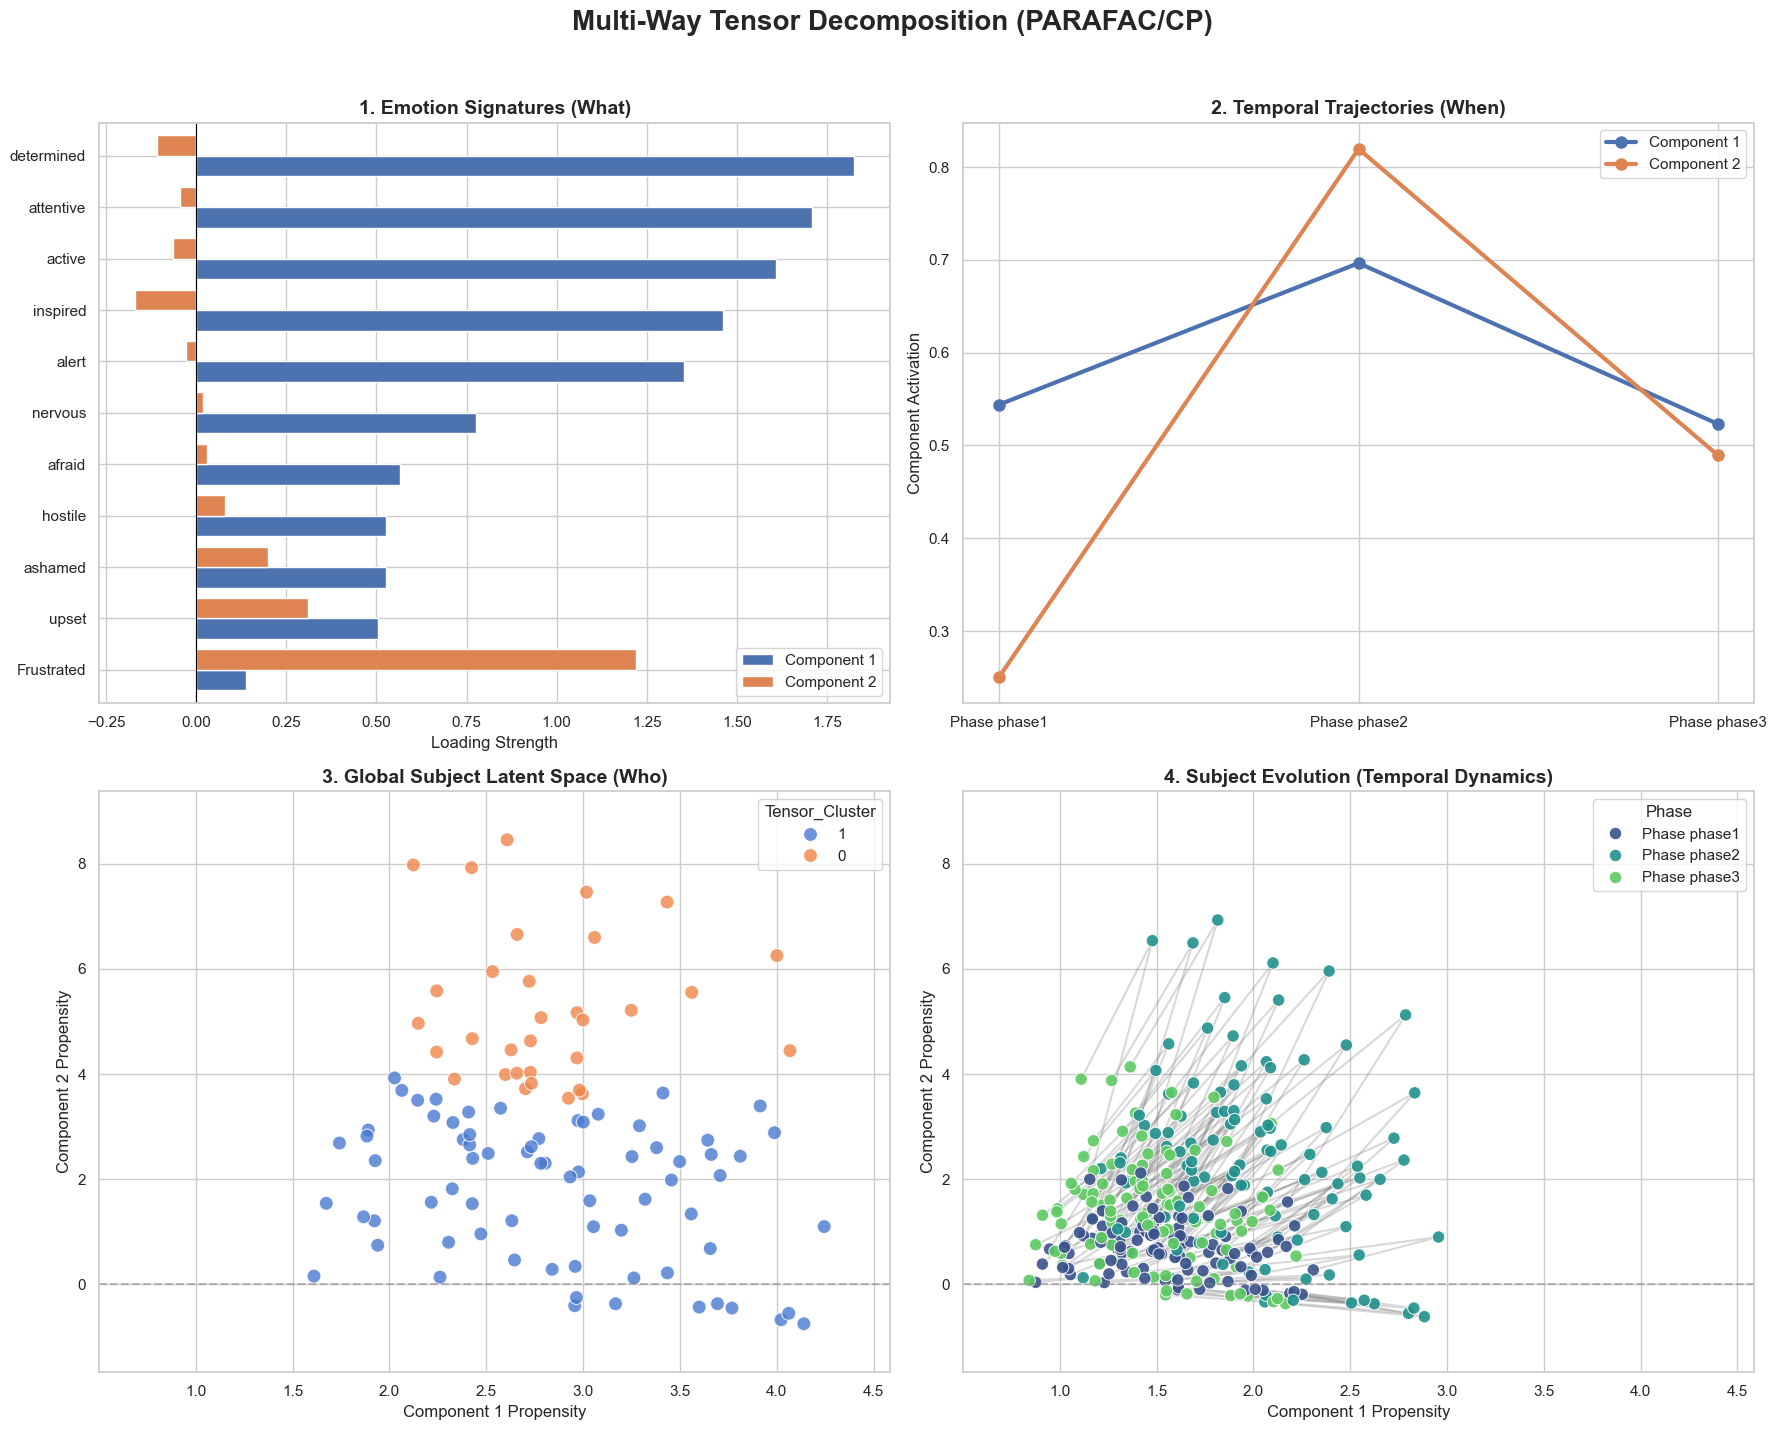

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Check for tensorly installation
try:
    import tensorly as tl
    from tensorly.decomposition import parafac
    TENSORLY_AVAILABLE = True
except ImportError:
    print("WARNING: 'tensorly' library is not installed. Please run 'pip install tensorly'.")
    TENSORLY_AVAILABLE = False

if TENSORLY_AVAILABLE:
    # --- 1. SETUP & DATA LOADING ---
    base_path = Path(os.getcwd()).resolve().parents[0] 
    df_raw = pd.read_csv(base_path / 'data' / 'processed' / 'HR_data_2.csv')

    questionnaire_cols = [
        'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 
        'nervous', 'attentive', 'afraid', 'active', 'determined'
    ]

    # --- 2. TENSOR CREATION (Subjects x Emotions x Phases) ---
    print("Building 3D Tensor Structure...")
    if 'Subject_ID' not in df_raw.columns:
        df_raw['Subject_ID'] = df_raw.groupby('Phase').cumcount()

    df_clean = df_raw.dropna(subset=questionnaire_cols)
    
    subjects = sorted(df_clean['Subject_ID'].unique())
    phases = sorted(df_clean['Phase'].unique())
    
    I, J, K = len(subjects), len(questionnaire_cols), len(phases)

    tensor_data = np.full((I, J, K), np.nan)
    for k_idx, phase in enumerate(phases):
        phase_data = df_clean[df_clean['Phase'] == phase]
        for i_idx, subj in enumerate(subjects):
            subj_data = phase_data[phase_data['Subject_ID'] == subj]
            if not subj_data.empty:
                tensor_data[i_idx, :, k_idx] = subj_data[questionnaire_cols].values[0]

    if np.isnan(tensor_data).any():
        for j in range(J):
            emot_median = np.nanmedian(tensor_data[:, j, :])
            mask = np.isnan(tensor_data[:, j, :])
            tensor_data[:, j, :][mask] = emot_median

    # --- 3. PARAFAC DECOMPOSITION ---
    R = 2 
    print(f"Running PARAFAC Decomposition (Rank={R})...")
    weights, factor_matrices = parafac(tensor_data, rank=R, init='random', random_state=42)
    subject_factors, emotion_factors, phase_factors = factor_matrices

    # --- 4. VISUALIZATION (2x2 GRID) ---
    print("Generating 2x2 Interpretation Grid...")
    sns.set_theme(style="whitegrid", palette="muted")
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14)) 
    comp_colors = ['#4C72B0', '#DD8452']

    # --- TOP-LEFT: PLOT 1 (Emotions) ---
    df_emot = pd.DataFrame(emotion_factors * weights, index=questionnaire_cols, 
                           columns=['Component 1', 'Component 2']).sort_values(by='Component 1')
    df_emot.plot(kind='barh', ax=axes[0, 0], color=comp_colors, width=0.8)
    axes[0, 0].set_title('1. Emotion Signatures (What)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Loading Strength')
    axes[0, 0].axvline(0, color='black', linewidth=0.8)

    # --- TOP-RIGHT: PLOT 2 (Phases) ---
    df_phase = pd.DataFrame(phase_factors, index=[f'Phase {p}' for p in phases], 
                            columns=['Component 1', 'Component 2'])
    df_phase.plot(kind='line', marker='o', markersize=8, linewidth=3, ax=axes[0, 1], color=comp_colors)
    axes[0, 1].set_title('2. Temporal Trajectories (When)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Component Activation')
    axes[0, 1].set_xticks(range(len(phases)))
    axes[0, 1].set_xticklabels([f'Phase {p}' for p in phases])

    # --- DATA PREP FOR BOTTOM PLOTS (Subjects) ---
    # Global Subject Positions
    gmm_parafac = GaussianMixture(n_components=2, random_state=42)
    subj_clusters = gmm_parafac.fit_predict(subject_factors)
    df_subj = pd.DataFrame(subject_factors, columns=['Component 1', 'Component 2'])
    df_subj['Tensor_Cluster'] = subj_clusters.astype(str)
    
    # Dynamic Subject Positions per Phase
    phase_points = []
    for i_idx, subj in enumerate(subjects):
        for k_idx, phase in enumerate(phases):
            c1_dynamic = subject_factors[i_idx, 0] * phase_factors[k_idx, 0]
            c2_dynamic = subject_factors[i_idx, 1] * phase_factors[k_idx, 1]
            phase_points.append({
                'Subject_ID': subj,
                'Component 1': c1_dynamic,
                'Component 2': c2_dynamic,
                'Phase': f'Phase {phase}'
            })
    df_phase_space = pd.DataFrame(phase_points)

    # Calculate global axis limits to lock both plots
    x_min = min(df_subj['Component 1'].min(), df_phase_space['Component 1'].min())
    x_max = max(df_subj['Component 1'].max(), df_phase_space['Component 1'].max())
    y_min = min(df_subj['Component 2'].min(), df_phase_space['Component 2'].min())
    y_max = max(df_subj['Component 2'].max(), df_phase_space['Component 2'].max())
    pad_x, pad_y = (x_max - x_min) * 0.1, (y_max - y_min) * 0.1

    # --- BOTTOM-LEFT: PLOT 3 (Global Subjects) ---
    sns.scatterplot(data=df_subj, x='Component 1', y='Component 2', 
                    hue='Tensor_Cluster', s=100, alpha=0.8, ax=axes[1, 0])
    axes[1, 0].set_title('3. Global Subject Latent Space (Who)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Component 1 Propensity')
    axes[1, 0].set_ylabel('Component 2 Propensity')

    # --- BOTTOM-RIGHT: PLOT 4 (Subjects Dynamics with Trajectories) ---
    # Draw trajectory lines connecting the phases for each subject
    for subj in subjects:
        subj_data = df_phase_space[df_phase_space['Subject_ID'] == subj]
        axes[1, 1].plot(subj_data['Component 1'], subj_data['Component 2'], 
                        color='gray', alpha=0.3, linewidth=1.5, zorder=1)
    
    # Draw the scatter points on top
    sns.scatterplot(data=df_phase_space, x='Component 1', y='Component 2', 
                    hue='Phase', palette='viridis', s=80, alpha=0.9, ax=axes[1, 1], zorder=2)
    axes[1, 1].set_title('4. Subject Evolution (Temporal Dynamics)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Component 1 Propensity')
    axes[1, 1].set_ylabel('Component 2 Propensity')

    # Lock the axes for perfect comparability
    for ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlim(x_min - pad_x, x_max + pad_x)
        ax.set_ylim(y_min - pad_y, y_max + pad_y)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

    plt.suptitle('Multi-Way Tensor Decomposition (PARAFAC/CP)', fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

ARI NMI to evaluate clusters

In [17]:
import numpy as np
import pandas as pd
import tensorly as tl
from tensorly.decomposition import parafac
import matplotlib.pyplot as plt

# 1. Prepare the Tensor (Assuming df has columns: 'Individual', 'Phase', 'Feature1', 'Feature2'...)
# We need to reshape the dataframe into a 3D numpy array: (n_subjects, n_phases, n_features)

# Sort and group to ensure consistent ordering
features = ['Mean_HR', 'Mean_EDA', 'Mean_TEMP'] # Add your actual feature names
n_subjects = df['Individual'].nunique()
n_phases = 3 # Pre-puzzle, Puzzle, Post-puzzle
n_features = len(features)

# Initialize empty tensor
tensor_data = np.zeros((n_subjects, n_phases, n_features))

# Fill the tensor (ensure your data is scaled/normalized beforehand!)
subjects = df['Individual'].unique()
phases = ['phase1', 'phase2', 'phase3'] # Adjust to your actual phase names

for i, sub in enumerate(subjects):
    for j, phase in enumerate(phases):
        # Extract the row for this subject and phase
        mask = (df['Individual'] == sub) & (df['Phase'] == phase)
        if mask.sum() > 0:
            tensor_data[i, j, :] = df.loc[mask, features].values[0]

# 2. Apply PARAFAC Decomposition
# Set the backend to numpy
tl.set_backend('numpy')

# Rank is the number of components (similar to n_components in PCA)
n_components = 2 
weights, factors = parafac(tensor_data, rank=n_components, init='random', random_state=42)

# Factors is a list of 3 matrices: [Subject_Matrix, Phase_Matrix, Feature_Matrix]
subject_factors = factors[0] # Shape: (26, 2)
phase_factors = factors[1]   # Shape: (3, 2)
feature_factors = factors[2] # Shape: (n_features, 2)

# 3. Interpret the Results
# Plotting the Phase Factors to see how latent states change over time
plt.plot(phases, phase_factors[:, 0], label='Component 1', marker='o')
plt.plot(phases, phase_factors[:, 1], label='Component 2', marker='x')
plt.title("Latent Components Across Experimental Phases")
plt.legend()
plt.show()

KeyError: "None of [Index(['Mean_HR', 'Mean_EDA', 'Mean_TEMP'], dtype='str')] are in the [columns]"